In [1]:
import os
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Functions

In [2]:
# plot target drift
def plot_target_drift(df_train, df_valid, df_test, str_target, str_filename='output/target_drift.png'):
    list_labels = ['Train', 'Validation', 'Test']
    list_means = [df_train[str_target].mean(), df_valid[str_target].mean(), df_test[str_target].mean()]
    # plot
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(list_labels, list_means, color='steelblue', edgecolor='black')
    ax.set_title('Target Drift', fontsize=16)
    ax.set_xlabel('Split', fontsize=12)
    ax.set_ylabel('Target Mean', fontsize=12)
    # annotate bars
    for i, flt_mean in enumerate(list_means):
        ax.text(i, flt_mean + (ax.get_ylim()[1] * 0.01), f'{flt_mean:.4f}', ha='center', fontsize=11)
    # pad the top so labels don't clip
    ax.set_ylim(top=ax.get_ylim()[1] * 1.15)
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

In [3]:
# plot observations by split
def plot_observations(df_train, df_valid, df_test, str_filename='output/observations_by_split.png'):
    list_labels = ['Train', 'Validation', 'Test']
    list_counts = [len(df_train), len(df_valid), len(df_test)]
    int_total = sum(list_counts)
    # plot
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(list_labels, list_counts, color='steelblue', edgecolor='black')
    ax.set_title('Observations by Split', fontsize=16)
    ax.set_xlabel('Split', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    # annotate bars with count and percent
    for i, int_count in enumerate(list_counts):
        flt_pct = int_count / int_total * 100
        ax.text(i, int_count + (ax.get_ylim()[1] * 0.01), f'{int_count:,}\n({flt_pct:.1f}%)', ha='center', fontsize=11)
    # pad the top so labels don't clip
    ax.set_ylim(top=ax.get_ylim()[1] * 1.15)
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

#### Constants

In [4]:
# bucket
str_bucket = os.getcwd().split('/')[4].replace('_', '-')
print(f'Bucket: {str_bucket}')

# step
str_step = os.getcwd().split('/')[-1]
print(f'Step: {str_step}')

# s3 path
str_s3_path = f's3://{str_bucket}/00_data_collection/data.csv'
print(f'S3 Path: {str_s3_path}')

# target
str_target = 'default_12m'
print(f'Target: {str_target}')

# date column
str_date_col = 'origination_date'
print(f'Date Column: {str_date_col}')

# split proportions
flt_train = 0.70
flt_valid = 0.15
flt_test = 0.15

# output directory
os.makedirs('output', exist_ok=True)

Bucket: credit-risk-claude
Step: 02_data_split
S3 Path: s3://credit-risk-claude/00_data_collection/data.csv
Target: default_12m
Date Column: origination_date


#### Read Data

In [5]:
# read data
df = pd.read_csv(str_s3_path)

# convert date column
df[str_date_col] = pd.to_datetime(df[str_date_col])

# sort by date
df = df.sort_values(str_date_col).reset_index(drop=True)

# shape
print(f'Shape: {df.shape}')
df.head()

/home/ec2-user/anaconda3/envs/tensorflow2_p310/lib/python3.12/site-packages/fsspec/registry.py:301: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


Shape: (25308, 20)


,loan_id,origination_date,dob,loan_amount,term_months,channel,employment_length_years,stated_income,state,has_prior_loans_with_us,bureau_score,open_trades,delinq_12m,utilization,inquiries_6m,public_records,default_12m,charged_off_amount,paid_interest_amount,apr
0,17794,2022-01-01,2/29/1992,5410,18,partner,8.39,2951.0,WI,0,604.0,1.0,1.0,0.47,3.0,1,0,0.0,1715.89,0.221
1,13499,2022-01-01,5/5/1966,10000,12,web,4.52,5410.0,FL,0,600.0,2.0,0.0,0.46,3.0,0,0,0.0,1672.59,0.209
2,24476,2022-01-01,2/6/1985,8480,12,web,3.81,3244.0,TX,0,557.0,2.0,0.0,0.48,5.0,2,0,0.0,2379.19,0.303
3,5438,2022-01-01,11/6/1981,3510,18,web,9.82,5147.0,IL,1,651.0,3.0,0.0,0.18,1.0,0,0,0.0,706.84,0.150
4,11493,2022-01-01,11/27/1991,6630,24,web,4.99,6389.0,TX,1,611.0,1.0,0.0,0.41,3.0,1,0,0.0,2160.10,0.159


#### Split Data

In [6]:
# split indices
int_n_rows = len(df)
int_train_end = int(int_n_rows * flt_train)
int_valid_end = int(int_n_rows * (flt_train + flt_valid))

# split
df_train = df.iloc[:int_train_end].reset_index(drop=True)
df_valid = df.iloc[int_train_end:int_valid_end].reset_index(drop=True)
df_test = df.iloc[int_valid_end:].reset_index(drop=True)

# summary
list_rows = []
for str_name, df_split in [('Train', df_train), ('Validation', df_valid), ('Test', df_test)]:
    list_rows.append({
        'str_split': str_name,
        'int_n_rows': df_split.shape[0],
        'int_n_cols': df_split.shape[1],
        'str_date_min': str(df_split[str_date_col].min().date()),
        'str_date_max': str(df_split[str_date_col].max().date()),
        'flt_target_mean': df_split[str_target].mean(),
    })
df_split_summary = pd.DataFrame(list_rows)
df_split_summary.to_csv('output/split_summary.csv', index=False)
df_split_summary

,str_split,int_n_rows,int_n_cols,str_date_min,str_date_max,flt_target_mean
0,Train,17715,20,2022-01-01,2024-02-02,0.189783
1,Validation,3796,20,2024-02-02,2024-07-18,0.177292
2,Test,3797,20,2024-07-18,2024-12-28,0.182513


#### Observations by Split

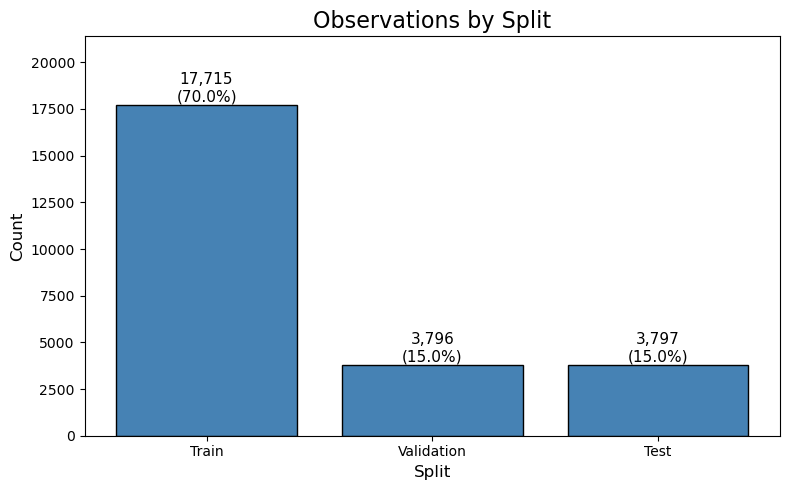

In [7]:
plot_observations(df_train, df_valid, df_test)

#### Target Drift

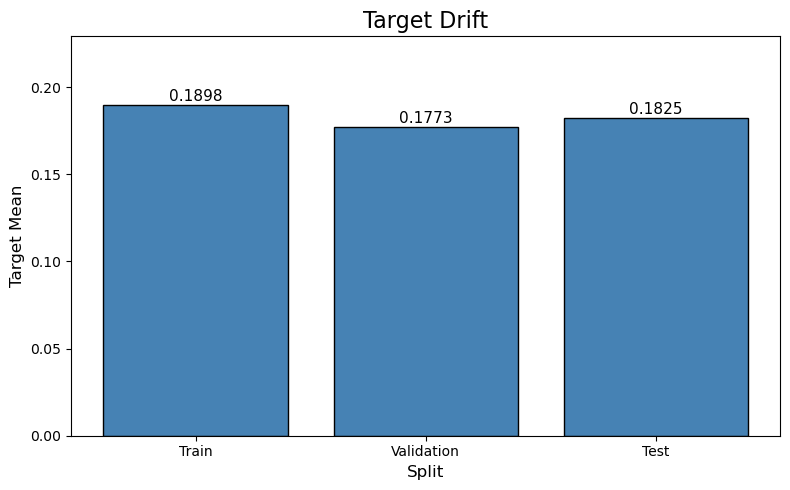

In [8]:
plot_target_drift(df_train, df_valid, df_test, str_target)

#### Save

In [9]:
# save to s3 as parquet
for str_name, df_split in [('df_train', df_train), ('df_valid', df_valid), ('df_test', df_test)]:
    str_s3_output = f's3://{str_bucket}/{str_step}/{str_name}.parquet'
    df_split.to_parquet(str_s3_output, index=False)
    print(f'{str_name} saved to {str_s3_output}')

df_train saved to s3://credit-risk-claude/02_data_split/df_train.parquet
df_valid saved to s3://credit-risk-claude/02_data_split/df_valid.parquet
df_test saved to s3://credit-risk-claude/02_data_split/df_test.parquet
